## Реализация перцептрона на python по книге Себастьяна Рашки

In [101]:
help(zip)

Help on class zip in module builtins:

class zip(object)
 |  zip(*iterables, strict=False)
 |
 |  The zip object yields n-length tuples, where n is the number of iterables
 |  passed as positional arguments to zip().  The i-th element in every tuple
 |  comes from the i-th iterable argument to zip().  This continues until the
 |  shortest argument is exhausted.
 |
 |  If strict is true and one of the arguments is exhausted before the others,
 |  raise a ValueError.
 |
 |     >>> list(zip('abcdefg', range(3), range(4)))
 |     [('a', 0, 0), ('b', 1, 1), ('c', 2, 2)]
 |
 |  Methods defined here:
 |
 |  __iter__(self, /)
 |      Implement iter(self).
 |
 |  __next__(self, /)
 |      Implement next(self).
 |
 |  __reduce__(self, /)
 |      Return state information for pickling.
 |
 |  __setstate__(self, object, /)
 |      Set state information for unpickling.
 |
 |  ----------------------------------------------------------------------
 |  Static methods defined here:
 |
 |  __new__(*args,

In [102]:
import numpy as np

class Perceptron(object):

    def __init__(self, eta=0.1, iterations=10):
        self.eta = eta
        self.iterations = iterations
    
    def fit(self, X, y):
        self.weights = np.zeros(1 + X.shape[1])
        self.errors = []

        for _ in range(self.iterations):
            err = 0
            for x_i, target in zip(X, y):
                update = self.eta * (target - self.predict(x_i))
                self.weights[1:] += update * x_i
                self.weights[0] += update
                err += int(update != 0.0)
            self.errors.append(err)
        return self
    
    def net_input(self, X):
        return np.dot(X, self.weights[1:]) + self.weights[0]

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, -1)



In [103]:
import pandas as pd
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
df = pd.read_csv(url, header=None)
df.tail()

,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [104]:
help(pd.DataFrame.iloc)

Help on property:

iloc
    Purely integer-location based indexing for selection by position.

    .. versionchanged:: 3.0

       Callables which return a tuple are deprecated as input.

    ``.iloc[]`` is primarily integer position based (from ``0`` to
    ``length-1`` of the axis), but may also be used with a boolean
    array.

    Allowed inputs are:

    - An integer, e.g. ``5``.
    - A list or array of integers, e.g. ``[4, 3, 0]``.
    - A slice object with ints, e.g. ``1:7``.
    - A boolean array.
    - A ``callable`` function with one argument (the calling Series or
      DataFrame) and that returns valid output for indexing (one of the above).
      This is useful in method chains, when you don't have a reference to the
      calling object, but would like to base your selection on
      some value.
    - A tuple of row and column indexes. The tuple elements consist of one of the
      above inputs, e.g. ``(0, 1)``.

    ``.iloc`` will raise ``IndexError`` if a requested in

In [105]:
y = df.iloc[0:100, 4].values
y = np.where(y == 'Iris-setosa', -1, 1)
X = df.iloc[0:100, [0, 2]].values

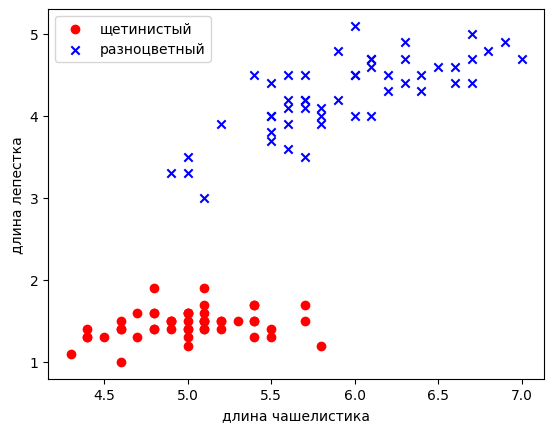

In [106]:
from matplotlib import pyplot as plt

plt.scatter(X[0:50, 0], X[0:50, 1], label='щетинистый', color='red', marker='o')
plt.scatter(X[50:, 0], X[50:, 1], label='разноцветный', color='blue', marker='x')
plt.xlabel('длина чашелистика')
plt.ylabel('длина лепестка')
plt.legend(loc='upper left')
plt.show()

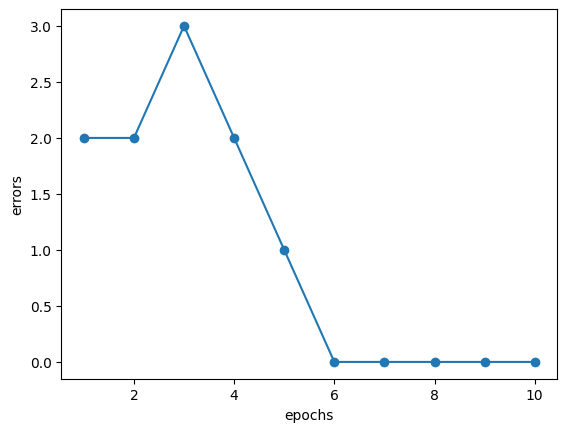

In [107]:
perceptron = Perceptron()
perceptron.fit(X, y)
plt.plot(range(1, len(perceptron.errors) + 1), perceptron.errors, marker='o')
plt.xlabel('epochs')
plt.ylabel('errors')
plt.show()

In [108]:
help(np.arange)

Help on built-in function arange in module numpy:

arange(
    start_or_stop,
    /,
    stop=None,
    step=1,
    *,
    dtype=None,
    device=None,
    like=None
)
    arange([start,] stop[, step,], dtype=None, *, device=None, like=None)

    Return evenly spaced values within a given interval.

    ``arange`` can be called with a varying number of positional arguments:

    * ``arange(stop)``: Values are generated within the half-open interval
      ``[0, stop)`` (in other words, the interval including `start` but
      excluding `stop`).
    * ``arange(start, stop)``: Values are generated within the half-open
      interval ``[start, stop)``.
    * ``arange(start, stop, step)`` Values are generated within the half-open
      interval ``[start, stop)``, with spacing between values given by
      ``step``.

    For integer arguments the function is roughly equivalent to the Python
    built-in :py:class:`range`, but returns an ndarray rather than a ``range``
    instance.

    When

In [109]:
help(np.meshgrid)

Help on method descriptor meshgrid in module numpy:

meshgrid(*xi, copy=True, sparse=False, indexing='xy')
    Return a tuple of coordinate matrices from coordinate vectors.

    Make N-D coordinate arrays for vectorized evaluations of
    N-D scalar/vector fields over N-D grids, given
    one-dimensional coordinate arrays x1, x2,..., xn.

    Parameters
    ----------
    x1, x2,..., xn : array_like
        1-D arrays representing the coordinates of a grid.
    indexing : {'xy', 'ij'}, optional
        Cartesian ('xy', default) or matrix ('ij') indexing of output.
        See Notes for more details.
    sparse : bool, optional
        If True the shape of the returned coordinate array for dimension *i*
        is reduced from ``(N1, ..., Ni, ... Nn)`` to
        ``(1, ..., 1, Ni, 1, ..., 1)``.  These sparse coordinate grids are
        intended to be used with :ref:`basics.broadcasting`.  When all
        coordinates are used in an expression, broadcasting still leads to a
        ful

In [113]:
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, resolution=0.02):
    markers = ['o', 'x', 's', '^', 'v']
    colors = ['red', 'blue', 'lightgreen', 'gray', 'cyan']
    cmap = ListedColormap(colors[:len(np.unique(y))])

    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution), np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([np.ravel(xx1), np.ravel(xx2)]).T)
    Z = Z.reshape(np.shape(xx1))
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(np.min(xx1), np.max(xx1))
    plt.ylim(np.min(xx2), np.max(xx2))
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1], alpha = 0.8, c=cmap(idx), marker=markers[idx], label = cl)
    

In [114]:
help(plt.contourf)

Help on function contourf in module matplotlib.pyplot:

contourf(*args, data=None, **kwargs) -> QuadContourSet
    Plot filled contours.

    Call signature::

        contourf([X, Y,] Z, /, [levels], **kwargs)

    The arguments *X*, *Y*, *Z* are positional-only.

    `.contour` and `.contourf` draw contour lines and filled contours,
    respectively.  Except as noted, function signatures and return values
    are the same for both versions.

    Parameters
    ----------
    X, Y : array-like, optional
        The coordinates of the values in *Z*.

        *X* and *Y* must both be 2D with the same shape as *Z* (e.g.
        created via `numpy.meshgrid`), or they must both be 1-D such
        that ``len(X) == N`` is the number of columns in *Z* and
        ``len(Y) == M`` is the number of rows in *Z*.

        *X* and *Y* must both be ordered monotonically.

        If not given, they are assumed to be integer indices, i.e.
        ``X = range(N)``, ``Y = range(M)``.

    Z : (M, N) a

C:\Users\anton\AppData\Local\Temp\ipykernel_8756\3753552218.py:17: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1], alpha = 0.8, c=cmap(idx), marker=markers[idx], label = cl)


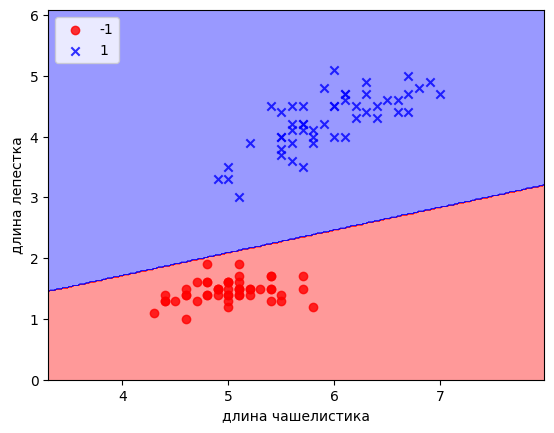

In [115]:
plot_decision_regions(X, y, classifier=perceptron)
plt.xlabel('длина чашелистика')
plt.ylabel('длина лепестка')
plt.legend(loc='upper left')
plt.show()